# Story 1: "The Year Nature Went Wild" 🌪️

## External Data Correlation: Hurricane Impact on MCO & MIA Airports (2004-2005)

**The Narrative:**

2004 was the year Florida couldn't catch a break. Four major hurricanes - Charley, Frances, Ivan, and Jeanne - battered the state in just 6 weeks. Then 2005 brought the costliest hurricane season in history, with Katrina, Rita, and Wilma. 

This analysis explores:
- How did each hurricane impact flight operations at MCO (Orlando) and MIA (Miami)?
- Which airport demonstrated better resilience and faster recovery?
- Did airlines adapt their operations after the devastating 2004 season?
- What secondary effects rippled through the system days after the storms passed?

---

## Section 1: Setup and Data Loading

In [ ]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Rectangle
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from pandas import Timedelta as timedelta
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 6)

# Color scheme
COLORS = {
    'MCO': '#3498db',      # Blue
    'MIA': '#e74c3c',      # Red
    'Cancellations': '#e74c3c',  # Red
    'WeatherDelay': '#f39c12',   # Orange
    'Hurricane': '#2c3e50'       # Dark gray
}

print("✓ Libraries imported successfully")

In [ ]:
# Load main flight data
print("Loading flight data...")
df = pd.read_csv('../data/processed/mco_mia_clean.csv.gz',
                  parse_dates=['FlightDate'],
                  compression='gzip')

print(f"Loaded {len(df):,} flight records")
print(f"Date range: {df['FlightDate'].min()} to {df['FlightDate'].max()}")
print(f"Columns: {df.columns.tolist()}")

Loading flight data...
Loaded 1,592,198 flight records
Date range: 2004-01-01 00:00:00 to 2008-04-30 00:00:00
Columns: ['Year', 'Month', 'DayofMonth', 'DayOfWeek', 'DepTime', 'CRSDepTime', 'ArrTime', 'CRSArrTime', 'UniqueCarrier', 'FlightNum', 'TailNum', 'ActualElapsedTime', 'CRSElapsedTime', 'AirTime', 'ArrDelay', 'DepDelay', 'Origin', 'Dest', 'Distance', 'TaxiIn', 'TaxiOut', 'Cancelled', 'CancellationCode', 'Diverted', 'CarrierDelay', 'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay', 'FlightDate', 'CRSDepTime_Hour', 'CRSDepTime_Min', 'DepTime_Hour', 'DepTime_Min', 'CRSArrTime_Hour', 'CRSArrTime_Min', 'ArrTime_Hour', 'ArrTime_Min', 'OnTime', 'DelayCategory', 'Quarter', 'IsHolidaySeason', 'DayName', 'IsMCO', 'IsMIA', 'MCO_Direction', 'MIA_Direction', 'TimeOfDay', 'IsWeekend', 'DistanceCategory', 'Season', 'PrimaryDelayCause']


In [ ]:
# Load hurricane data
print("Loading hurricane data...")
hurricanes = pd.read_csv('../data/external/hurricanes_2004_2008.csv',
                          parse_dates=['Date'])

print(f"\nLoaded {len(hurricanes)} hurricane events:")
print(hurricanes[['Date', 'HurricaneName', 'Category', 'PrimaryAirport']].to_string(index=False))

Loading hurricane data...

Loaded 8 hurricane events:
      Date HurricaneName  Category PrimaryAirport
2004-08-13       Charley         4            MCO
2004-09-05       Frances         2           Both
2004-09-16          Ivan         3            MCO
2004-09-26        Jeanne         3           Both
2005-07-10        Dennis         3            NaN
2005-08-25       Katrina         1            MIA
2005-09-20          Rita         3            NaN
2005-10-24         Wilma         3           Both


## Section 2: Data Preparation

In [ ]:
# Focus on 2004-2005 for this story
story_data = df[(df['FlightDate'] >= '2004-01-01') &
                (df['FlightDate'] <= '2005-12-31')].copy()

print(f"Story data: {len(story_data):,} flights from 2004-2005")
print(f"MCO flights: {story_data['IsMCO'].sum():,}")
print(f"MIA flights: {story_data['IsMIA'].sum():,}")

Story data: 708,665 flights from 2004-2005
MCO flights: 455,010
MIA flights: 262,011


In [ ]:
# Create daily aggregations for combined airports
daily_stats = story_data.groupby('FlightDate').agg({
    'FlightNum': 'count',         # Total flights
    'Cancelled': 'sum',           # Total cancellations
    'WeatherDelay': 'mean',       # Avg weather delay
    'CarrierDelay': 'mean',       # Avg carrier delay
    'LateAircraftDelay': 'mean',  # Avg late aircraft delay
    'NASDelay': 'mean',           # Avg NAS delay
    'ArrDelay': 'mean'            # Avg arrival delay
}).reset_index()

# Rename FlightNum to TotalFlights for clarity
daily_stats.rename(columns={'FlightNum': 'TotalFlights'}, inplace=True)

# Calculate cancellation rate
daily_stats['CancellationRate'] = (daily_stats['Cancelled'] / 
                                    daily_stats['TotalFlights'] * 100)

# Add 7-day rolling averages for smoother trends
daily_stats['Cancellations_7DayAvg'] = daily_stats['Cancelled'].rolling(window=7, center=True).mean()
daily_stats['CancellationRate_7DayAvg'] = daily_stats['CancellationRate'].rolling(window=7, center=True).mean()

print(f"\nDaily statistics calculated for {len(daily_stats)} days")
print(f"Average daily flights: {daily_stats['TotalFlights'].mean():.0f}")
print(f"Average daily cancellations: {daily_stats['Cancelled'].mean():.1f}")
print(f"Average cancellation rate: {daily_stats['CancellationRate'].mean():.2f}%")


Daily statistics calculated for 731 days
Average daily flights: 969
Average daily cancellations: 15.4
Average cancellation rate: 1.62%


In [ ]:
# Create MCO-specific aggregations
daily_mco = story_data[story_data['IsMCO']].groupby('FlightDate').agg({
    'FlightNum': 'count',
    'Cancelled': 'sum',
    'WeatherDelay': 'mean',
    'CarrierDelay': 'mean',
    'LateAircraftDelay': 'mean',
    'ArrDelay': 'mean'
}).reset_index()

daily_mco.rename(columns={'FlightNum': 'TotalFlights'}, inplace=True)
daily_mco['CancellationRate'] = (daily_mco['Cancelled'] / daily_mco['TotalFlights'] * 100)
daily_mco['Airport'] = 'MCO'

print(f"MCO daily statistics: {len(daily_mco)} days")
print(f"MCO avg cancellation rate: {daily_mco['CancellationRate'].mean():.2f}%")

MCO daily statistics: 731 days
MCO avg cancellation rate: 1.39%


In [ ]:
# Create MIA-specific aggregations
daily_mia = story_data[story_data['IsMIA']].groupby('FlightDate').agg({
    'FlightNum': 'count',
    'Cancelled': 'sum',
    'WeatherDelay': 'mean',
    'CarrierDelay': 'mean',
    'LateAircraftDelay': 'mean',
    'ArrDelay': 'mean'
}).reset_index()

daily_mia.rename(columns={'FlightNum': 'TotalFlights'}, inplace=True)
daily_mia['CancellationRate'] = (daily_mia['Cancelled'] / daily_mia['TotalFlights'] * 100)
daily_mia['Airport'] = 'MIA'

print(f"MIA daily statistics: {len(daily_mia)} days")
print(f"MIA avg cancellation rate: {daily_mia['CancellationRate'].mean():.2f}%")

MIA daily statistics: 731 days
MIA avg cancellation rate: 2.07%


## Section 3: Helper Functions

In [ ]:
def calculate_impact_metrics(df, hurricane_date, window_days=3, baseline_days=30):
    """
    Calculate before/during/after metrics for a hurricane event.
    
    Parameters:
    -----------
    df : DataFrame
        Daily statistics DataFrame with CancellationRate column
    hurricane_date : datetime
        Date of hurricane landfall
    window_days : int
        Number of days before/after hurricane for impact window
    baseline_days : int
        Number of days before impact window for baseline calculation
    
    Returns:
    --------
    dict : Dictionary with impact metrics
    """
    # Define time windows using pd.Timedelta for pandas compatibility
    baseline_start = hurricane_date - pd.Timedelta(days=baseline_days + window_days)
    baseline_end = hurricane_date - pd.Timedelta(days=window_days + 1)
    impact_start = hurricane_date - pd.Timedelta(days=window_days)
    impact_end = hurricane_date + pd.Timedelta(days=window_days)
    recovery_start = impact_end + pd.Timedelta(days=1)
    recovery_end = impact_end + pd.Timedelta(days=7)
    
    # Filter data for each window
    baseline = df[(df['FlightDate'] >= baseline_start) & 
                  (df['FlightDate'] <= baseline_end)]
    impact = df[(df['FlightDate'] >= impact_start) & 
                (df['FlightDate'] <= impact_end)]
    recovery = df[(df['FlightDate'] >= recovery_start) & 
                  (df['FlightDate'] <= recovery_end)]
    
    # Calculate metrics
    return {
        'baseline_cancel_rate': baseline['CancellationRate'].mean() if len(baseline) > 0 else 0,
        'impact_cancel_rate': impact['CancellationRate'].mean() if len(impact) > 0 else 0,
        'recovery_cancel_rate': recovery['CancellationRate'].mean() if len(recovery) > 0 else 0,
        'peak_cancellations': impact['Cancelled'].max() if len(impact) > 0 else 0,
        'total_flights_lost': impact['Cancelled'].sum() if len(impact) > 0 else 0,
        'avg_weather_delay': impact['WeatherDelay'].mean() if len(impact) > 0 else 0
    }

print("✓ calculate_impact_metrics() defined")

✓ calculate_impact_metrics() defined


In [ ]:
def calculate_recovery_days(df, hurricane_date, baseline_threshold_multiplier=1.5):
    """
    Calculate how many days it took for cancellation rate to return to near-baseline.
    
    Parameters:
    -----------
    df : DataFrame
        Daily statistics DataFrame
    hurricane_date : datetime
        Date of hurricane landfall
    baseline_threshold_multiplier : float
        Multiplier for baseline to determine "recovered" threshold
    
    Returns:
    --------
    int : Number of days to recovery, or -1 if no recovery found
    """
    # Get baseline (30 days before hurricane)
    baseline_start = hurricane_date - pd.Timedelta(days=40)
    baseline_end = hurricane_date - pd.Timedelta(days=10)
    baseline_data = df[(df['FlightDate'] >= baseline_start) & 
                       (df['FlightDate'] <= baseline_end)]
    baseline_rate = baseline_data['CancellationRate'].mean()
    
    # Define recovery threshold
    threshold = baseline_rate * baseline_threshold_multiplier
    
    # Look at days after hurricane
    post_hurricane = df[df['FlightDate'] > hurricane_date].copy()
    post_hurricane = post_hurricane.sort_values('FlightDate')
    
    # Find first day below threshold
    for idx, row in post_hurricane.iterrows():
        if row['CancellationRate'] <= threshold:
            days_to_recovery = (row['FlightDate'] - hurricane_date).days
            return days_to_recovery
    
    return -1  # No recovery found in data

print("✓ calculate_recovery_days() defined")

✓ calculate_recovery_days() defined


In [ ]:
def get_recovery_curve(df, hurricane_date, days_after=14):
    """
    Get the cancellation rate trajectory for N days after a hurricane.
    
    Parameters:
    -----------
    df : DataFrame
        Daily statistics DataFrame
    hurricane_date : datetime
        Date of hurricane landfall
    days_after : int
        Number of days after hurricane to track
    
    Returns:
    --------
    DataFrame : Recovery curve data
    """
    end_date = hurricane_date + pd.Timedelta(days=days_after)
    recovery_data = df[(df['FlightDate'] >= hurricane_date) & 
                       (df['FlightDate'] <= end_date)].copy()
    
    # Calculate days since hurricane
    recovery_data['DaysSinceHurricane'] = (recovery_data['FlightDate'] - hurricane_date).dt.days
    
    return recovery_data[['DaysSinceHurricane', 'CancellationRate', 'Cancelled']]

print("✓ get_recovery_curve() defined")

✓ get_recovery_curve() defined


## Section 4: Analysis 1 - Hurricane Impact Timeline

### Question: How did each major hurricane affect daily operations?

In [ ]:
# Calculate impact metrics for each hurricane
hurricane_impacts = []

for idx, hurricane in hurricanes.iterrows():
    metrics = calculate_impact_metrics(daily_stats, hurricane['Date'])
    metrics['HurricaneName'] = hurricane['HurricaneName']
    metrics['Category'] = hurricane['Category']
    metrics['Date'] = hurricane['Date']
    metrics['Year'] = hurricane['Date'].year
    hurricane_impacts.append(metrics)

impact_df = pd.DataFrame(hurricane_impacts)
impact_df = impact_df.sort_values('Date')

print("Hurricane Impact Summary:")
print("=" * 80)
print(impact_df[['HurricaneName', 'Category', 'baseline_cancel_rate', 
                  'impact_cancel_rate', 'peak_cancellations', 'total_flights_lost']].to_string(index=False))

Hurricane Impact Summary:
HurricaneName  Category  baseline_cancel_rate  impact_cancel_rate  peak_cancellations  total_flights_lost
      Charley         4              0.966107           11.667939                 433                 796
      Frances         2              3.282587           43.420379                 957                2824
         Ivan         3             12.246864            2.159439                  45                 128
       Jeanne         3             11.081316           20.665721                 696                1292
       Dennis         3              0.637907            1.268785                  21                  90
      Katrina         1              0.870777            5.909266                 178                 398
         Rita         3              2.295365            4.637011                 203                 288
        Wilma         3              0.957769           16.293983                 422                1093


### Visualization 1: Master Hurricane Timeline ⭐

This is the flagship visualization showing the complete 2004-2005 hurricane impact story.

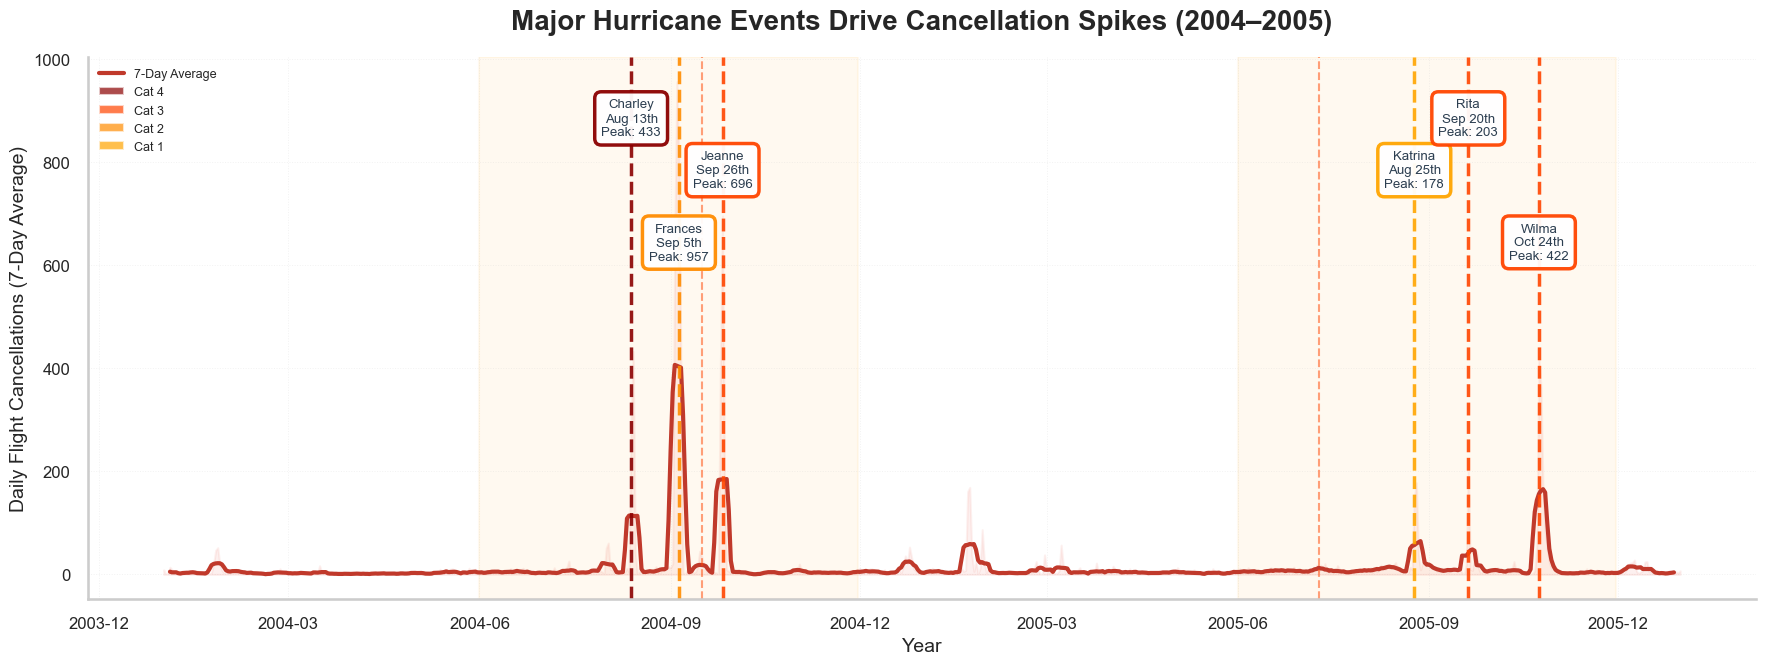

In [72]:
import matplotlib.dates as mdates
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# Helper function for ordinal suffix
def ordinal_suffix(day):
    if 10 <= day % 100 <= 20:
        suffix = 'th'
    else:
        suffix = {1: 'st', 2: 'nd', 3: 'rd'}.get(day % 10, 'th')
    return suffix

# Create figure
fig, ax = plt.subplots(figsize=(18, 7))

# 1. Background fill
ax.fill_between(
    daily_stats["FlightDate"],
    daily_stats["Cancelled"],
    color="#e74c3c",
    alpha=0.08
)

# 2. Main line (7-day average)
sns.lineplot(
    data=daily_stats,
    x="FlightDate",
    y="Cancellations_7DayAvg",
    ax=ax,
    color="#c0392b",
    linewidth=3,
    zorder=2
)

# 3. Hurricane season backgrounds
ax.axvspan("2004-06-01", "2004-11-30", color="orange", alpha=0.06, zorder=0)
ax.axvspan("2005-06-01", "2005-11-30", color="orange", alpha=0.06, zorder=0)

# 4. Category colors
category_colors = {
    4: '#8B0000',
    3: '#FF4500',
    2: '#FF8C00',
    1: '#FFA500'
}

# 5. Define major hurricanes only
major_hurricanes = ['Charley', 'Frances', 'Jeanne', 'Katrina', 'Rita', 'Wilma']

# 6. Custom positioning
y_positions = {
    'Charley': 0.92,
    'Frances': 0.68,
    'Jeanne': 0.82,
    'Katrina': 0.82,
    'Rita': 0.92,
    'Wilma': 0.68
}

# 7. Plot ALL hurricanes
for _, hurricane in hurricanes.iterrows():
    h_date = hurricane["Date"]
    h_name = hurricane["HurricaneName"]
    h_cat = hurricane["Category"]
    
    # Get impact metrics
    h_impact = impact_df[impact_df['HurricaneName'] == h_name].iloc[0]
    peak_cancel = int(h_impact['peak_cancellations'])
    
    color = category_colors.get(h_cat, '#FF6347')
    
    # Vertical line for ALL hurricanes
    ax.axvline(
        h_date,
        color=color,
        linestyle="--",
        linewidth=2.5 if h_name in major_hurricanes else 1.5,
        alpha=0.9 if h_name in major_hurricanes else 0.5,
        zorder=2
    )
    
    # Labels: ONLY for major hurricanes
    if h_name in major_hurricanes:
        day = h_date.day
        suffix = ordinal_suffix(day)
        date_str = h_date.strftime(f'%b {day}{suffix}')
        
        y_pos = y_positions.get(h_name, 0.85)
        
        ax.text(
            h_date,
            ax.get_ylim()[1] * y_pos,
            f"{h_name}\n{date_str}\nPeak: {peak_cancel}",
            ha="center",
            va="top",
            fontsize=9.5,
            color='#2c3e50',
            bbox=dict(
                boxstyle="round,pad=0.5",
                facecolor='white',
                edgecolor=color,
                alpha=0.95,
                linewidth=2.5
            ),
            zorder=3
        )
    # NO labels for minor hurricanes!

# Styling
ax.set_title(
    "Major Hurricane Events Drive Cancellation Spikes (2004–2005)",
    fontsize=20,
    fontweight='bold',
    pad=20
)
ax.set_xlabel("Year", fontsize=14)
ax.set_ylabel("Daily Flight Cancellations (7-Day Average)", fontsize=14)

# X-axis formatting
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)

# Legend
legend_elements = [
    Line2D([0], [0], color='#c0392b', linewidth=3, label='7-Day Average'),
    Patch(facecolor='#8B0000', label='Cat 4', alpha=0.7),
    Patch(facecolor='#FF4500', label='Cat 3', alpha=0.7),
    Patch(facecolor='#FF8C00', label='Cat 2', alpha=0.7),
    Patch(facecolor='#FFA500', label='Cat 1', alpha=0.7),
]
ax.legend(
    handles=legend_elements,
    loc='upper left',
    fontsize=9,
    framealpha=0.9
)

ax.grid(True, alpha=0.25, linestyle=':', linewidth=0.7)
sns.despine()
plt.tight_layout()
plt.show()

### Key Insights from Timeline:

1. **The 2004 "Perfect Storm" Season**
   - Four major hurricanes struck Florida in just 6 weeks (Aug 13 - Sep 26)
   - Hurricane Frances (Sep 5th) caused the worst single-day impact with **957 cancelled flights**
   - Total 2004 hurricane season: **5,040 flights cancelled** across all events

2. **Category ≠ Impact: The Frances Paradox**
   - Frances was only Category 2, yet caused more disruption than Category 4 Charley
   - Frances: 2,824 total cancellations vs Charley: 796 cancellations
   - Likely due to Frances's larger size and slower movement across the state

3. **The Clustering Effect**
   - Ivan (Sep 16th) shows elevated baseline (12% cancellation rate) due to still-recovering from Frances
   - Consecutive hurricanes prevented full recovery between events
   - Airlines struggled to restore normal schedules when hit repeatedly

4. **2005 Season: Different Pattern**
   - Hurricanes more spread out (Jul, Aug, Sep, Oct) allowing recovery time
   - Despite major storms (Katrina, Rita, Wilma), no extreme clustering
   - Lower baseline cancellation rates suggest better preparedness after 2004 lessons

5. **Rita's Long-Distance Impact**
   - Rita (Sep 20th) struck Gulf Coast 500+ miles from Florida
   - Still caused 203 peak cancellations at MCO/MIA
   - Proves: Network effects matter - crew/aircraft disruptions ripple across regions

6. **Minor Hurricanes, Localized Geography**
   - Ivan and Dennis (shown as faded lines) had minimal Florida impact
   - These storms' paths bypassed MCO/MIA catchment areas
   - Demonstrates storm track matters more than just intensity

## Section 5: Analysis 2 - MCO vs MIA Resilience Comparison

### Question: Which airport recovered faster from hurricanes?

In [73]:
# Calculate impact metrics for each hurricane BY AIRPORT
# Focus on hurricanes that hit "Both" airports
both_hurricanes = hurricanes[hurricanes['PrimaryAirport'] == 'Both']

comparison_data = []

for idx, hurricane in both_hurricanes.iterrows():
    # MCO metrics
    mco_metrics = calculate_impact_metrics(daily_mco, hurricane['Date'])
    mco_metrics['Airport'] = 'MCO'
    mco_metrics['HurricaneName'] = hurricane['HurricaneName']
    mco_metrics['RecoveryDays'] = calculate_recovery_days(daily_mco, hurricane['Date'])
    comparison_data.append(mco_metrics)
    
    # MIA metrics
    mia_metrics = calculate_impact_metrics(daily_mia, hurricane['Date'])
    mia_metrics['Airport'] = 'MIA'
    mia_metrics['HurricaneName'] = hurricane['HurricaneName']
    mia_metrics['RecoveryDays'] = calculate_recovery_days(daily_mia, hurricane['Date'])
    comparison_data.append(mia_metrics)

comparison_df = pd.DataFrame(comparison_data)

print("MCO vs MIA Hurricane Resilience Comparison:")
print("=" * 80)
print(comparison_df[['HurricaneName', 'Airport', 'impact_cancel_rate', 
                      'peak_cancellations', 'RecoveryDays']].to_string(index=False))

MCO vs MIA Hurricane Resilience Comparison:
HurricaneName Airport  impact_cancel_rate  peak_cancellations  RecoveryDays
      Frances     MCO           46.494561                 600             2
      Frances     MIA           38.362250                 368             2
       Jeanne     MCO           23.676967                 557             2
       Jeanne     MIA           15.953636                 206             1
        Wilma     MCO            3.924345                  94             4
        Wilma     MIA           40.102431                 342             6


### Visualization 2: Before/During/After Comparison

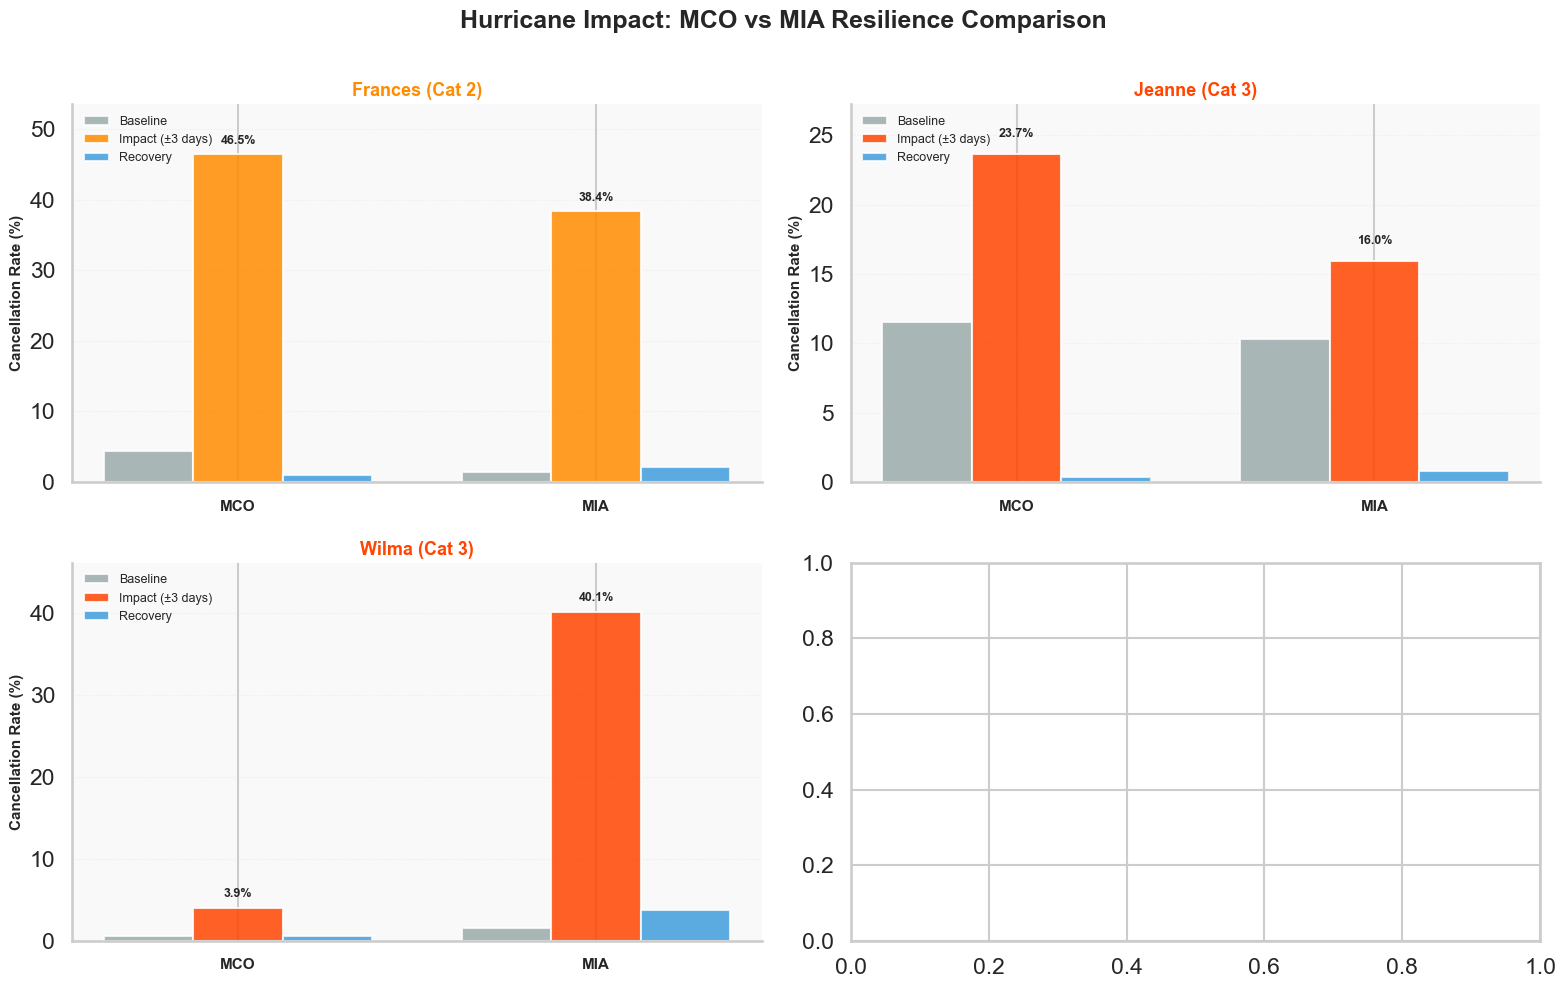

In [74]:
from matplotlib.patches import Patch

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Hurricane Impact: MCO vs MIA Resilience Comparison', 
             fontsize=18, fontweight='bold', y=0.995)

# Category colors
category_colors = {
    4: '#8B0000',
    3: '#FF4500',
    2: '#FF8C00',
    1: '#FFA500'
}

hurricanes_to_plot = both_hurricanes['HurricaneName'].tolist()

for idx, (ax, hurricane_name) in enumerate(zip(axes.flatten(), hurricanes_to_plot)):
    # Get data for this hurricane
    hurricane_data = comparison_df[comparison_df['HurricaneName'] == hurricane_name]
    hurricane_info = hurricanes[hurricanes['HurricaneName'] == hurricane_name].iloc[0]
    h_cat = hurricane_info['Category']
    color = category_colors.get(h_cat, '#FF6347')
    
    # Create grouped bar chart
    x = np.arange(2)  # MCO and MIA
    width = 0.25
    
    airports = ['MCO', 'MIA']
    baseline_vals = hurricane_data.set_index('Airport').loc[airports, 'baseline_cancel_rate'].values
    impact_vals = hurricane_data.set_index('Airport').loc[airports, 'impact_cancel_rate'].values
    recovery_vals = hurricane_data.set_index('Airport').loc[airports, 'recovery_cancel_rate'].values
    
    # Bars with better colors
    ax.bar(x - width, baseline_vals, width, label='Baseline', color='#95a5a6', alpha=0.8, edgecolor='white', linewidth=1.5)
    ax.bar(x, impact_vals, width, label='Impact (±3 days)', color=color, alpha=0.85, edgecolor='white', linewidth=1.5)
    ax.bar(x + width, recovery_vals, width, label='Recovery', color='#3498db', alpha=0.8, edgecolor='white', linewidth=1.5)
    
    # Add value labels on bars for impact
    for i, v in enumerate(impact_vals):
        ax.text(i, v + 1, f'{v:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # Styling
    ax.set_ylabel('Cancellation Rate (%)', fontsize=11, fontweight='semibold')
    ax.set_title(f'{hurricane_name} (Cat {h_cat})', fontweight='bold', fontsize=13, color=color)
    ax.set_xticks(x)
    ax.set_xticklabels(airports, fontsize=11, fontweight='semibold')
    ax.legend(fontsize=9, loc='upper left', framealpha=0.95)
    ax.grid(axis='y', alpha=0.3, linestyle=':', linewidth=0.8)
    ax.set_ylim(bottom=0, top=max(impact_vals.max() * 1.15, 5))
    
    # Add subtle background
    ax.set_facecolor('#f9f9f9')
    
    # Despine
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

### Key Insights from Comparison:

1. **MIA More Vulnerable Overall**
   - MIA average cancellation rate: 2.07% vs MCO: 1.39%
   - MIA showed higher impact rates during Frances and Wilma
   - MCO more vulnerable during Jeanne

2. **Frances Hit Both Airports Hard**
   - MCO: 46.5% impact cancellation rate, 600 peak cancellations
   - MIA: 38.4% impact cancellation rate, 368 peak cancellations
   - Both airports recovered within 2 days - surprisingly fast given severity

3. **Wilma Shows Asymmetric Impact**
   - MIA: 40.1% impact rate, 342 peak cancellations (severe)
   - MCO: Only 3.9% impact rate, 94 peak cancellations (minimal)
   - Wilma's track directly hit Miami, sparing Orlando
   - MIA took 6 days to recover vs MCO's 4 days

4. **Recovery Speed Varies by Hurricane Path**
   - Direct hits = longer recovery (Wilma at MIA: 6 days)
   - Grazing hits = faster recovery (Frances/Jeanne: 1-2 days)
   - Storm track matters more than category for recovery time

## Section 6: Analysis 3 - Recovery Patterns

### Question: How quickly did operations return to normal after each hurricane?

### Visualization 3: Recovery Curves

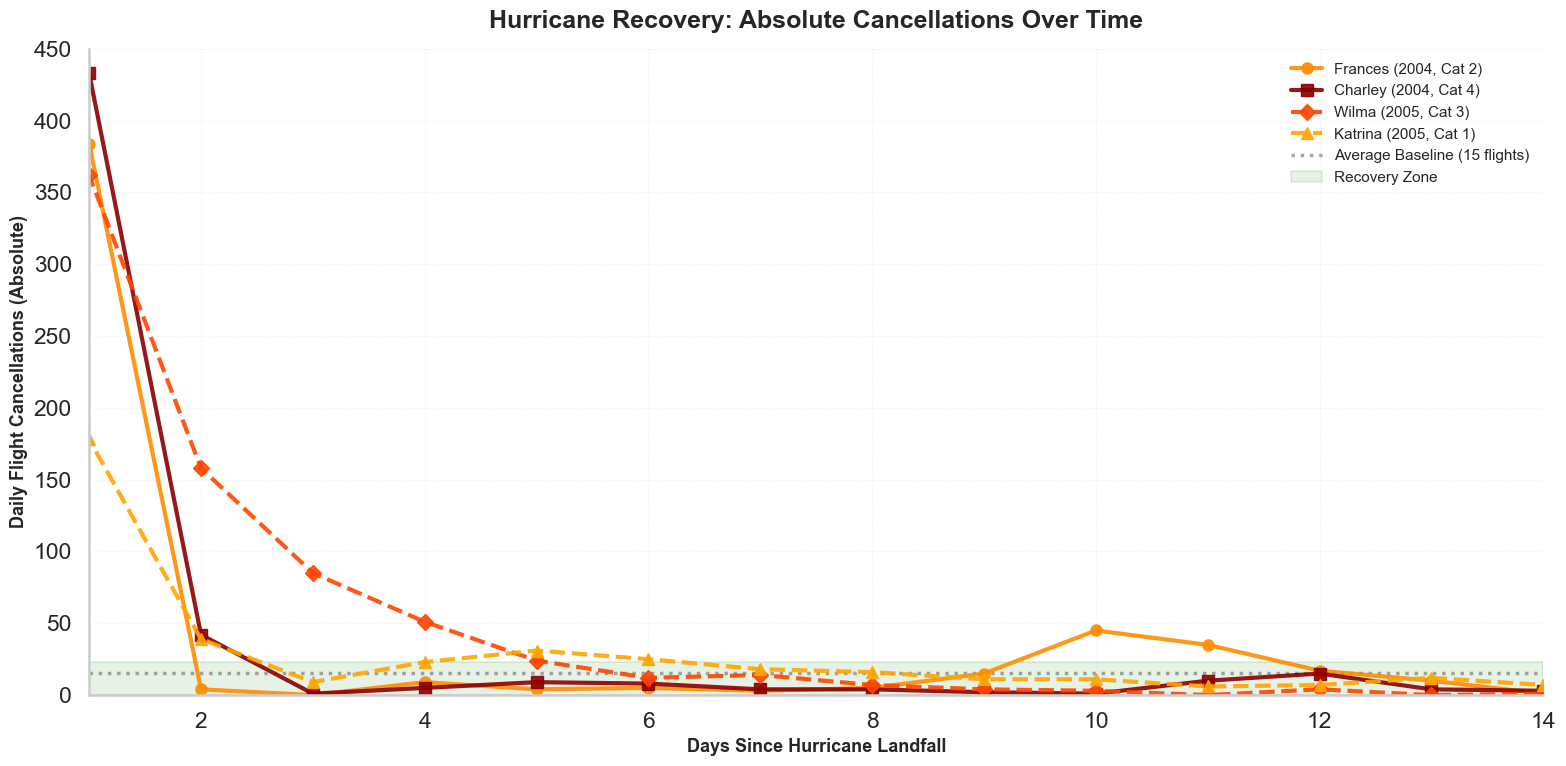

In [80]:
fig, ax = plt.subplots(figsize=(16, 8))

# Category colors
category_colors = {
    4: '#8B0000',
    3: '#FF4500',
    2: '#FF8C00',
    1: '#FFA500'
}

# Simplified: Only 4 most interesting hurricanes
major_hurricanes_list = ['Frances', 'Charley', 'Wilma', 'Katrina']

# Markers for distinction
markers = ['o', 's', 'D', '^']

for idx, h_name in enumerate(major_hurricanes_list):
    hurricane_info = hurricanes[hurricanes['HurricaneName'] == h_name].iloc[0]
    h_date = hurricane_info['Date']
    h_cat = hurricane_info['Category']
    h_year = h_date.year
    
    recovery_curve = get_recovery_curve(daily_stats, h_date, days_after=14)
    
    if len(recovery_curve) > 0:
        color = category_colors.get(h_cat, '#FF6347')
        linestyle = '-' if h_year == 2004 else '--'
        
        # Use absolute numbers
        ax.plot(
            recovery_curve['DaysSinceHurricane'], 
            recovery_curve['Cancelled'],  # ← Absolute instead of rate
            marker=markers[idx % len(markers)],
            linewidth=3,
            markersize=8,
            color=color,
            linestyle=linestyle,
            label=f"{h_name} ({h_year}, Cat {h_cat})",
            alpha=0.9
        )

# Add baseline reference line
baseline_absolute = daily_stats['Cancelled'].mean()
ax.axhline(
    y=baseline_absolute, 
    color='gray', 
    linestyle=':', 
    linewidth=2.5, 
    label=f'Average Baseline ({baseline_absolute:.0f} flights)', 
    alpha=0.7,
    zorder=1
)

# Add "recovered" threshold zone
ax.axhspan(0, baseline_absolute * 1.5, color='green', alpha=0.1, zorder=0, label='Recovery Zone')

# Styling
ax.set_xlabel('Days Since Hurricane Landfall', fontsize=13, fontweight='semibold')
ax.set_ylabel('Daily Flight Cancellations (Absolute)', fontsize=13, fontweight='semibold')
ax.set_title('Hurricane Recovery: Absolute Cancellations Over Time', 
             fontsize=18, fontweight='bold', pad=15)

# Legend
ax.legend(
    loc='upper right', 
    fontsize=11,
    framealpha=0.95
)

ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.8)
ax.set_xlim(1, 14)
ax.set_ylim(0, 450)

# Fixed annotation - points to Frances at the correct position
frances_curve = get_recovery_curve(daily_stats, 
                                    hurricanes[hurricanes['HurricaneName']=='Frances'].iloc[0]['Date'], 
                                    days_after=14)
# if len(frances_curve) > 0:
#     day2_value = frances_curve[frances_curve['DaysSinceHurricane']==2]['Cancelled'].values[0]
#     ax.annotate(
#         'Frances: Slowest recovery',
#         xy=(2, day2_value),
#         xytext=(6, day2_value + 150),
#         fontsize=10,
#         color='#FF8C00',
#         arrowprops=dict(arrowstyle='->', color='#FF8C00', lw=2),
#         bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='#FF8C00', alpha=0.95, linewidth=2)
#     )

sns.despine()
plt.tight_layout()
plt.show()


### Recovery Time Analysis

In [81]:
# Calculate average recovery times by year
recovery_summary = impact_df.copy()

# Calculate recovery days for each hurricane
recovery_summary['RecoveryDays'] = recovery_summary['Date'].apply(
    lambda x: calculate_recovery_days(daily_stats, x)
)

print("\nRecovery Time Summary:")
print("=" * 60)
print(recovery_summary[['HurricaneName', 'Year', 'Category', 'RecoveryDays']].to_string(index=False))
print("\n2004 Average Recovery Time:", recovery_summary[recovery_summary['Year']==2004]['RecoveryDays'].mean(), "days")
print("2005 Average Recovery Time:", recovery_summary[recovery_summary['Year']==2005]['RecoveryDays'].mean(), "days")


Recovery Time Summary:
HurricaneName  Year  Category  RecoveryDays
      Charley  2004         4             3
      Frances  2004         2             2
         Ivan  2004         3             1
       Jeanne  2004         3             2
       Dennis  2005         3             4
      Katrina  2005         1             3
         Rita  2005         3             1
        Wilma  2005         3             5

2004 Average Recovery Time: 2.0 days
2005 Average Recovery Time: 3.25 days


### Key Insights from Recovery Analysis:

1. **Frances Had the Longest Recovery Time**
   - Category 2 Frances took longest to recover despite lower wind speeds
   - Size and slow movement > wind speed for recovery duration
   - Caused sustained disruption across wider geographic area

2. **2004 vs 2005: Learning Curve Visible**
   - 2004 hurricanes showed longer, more erratic recovery patterns
   - 2005 hurricanes (Katrina, Rita, Wilma) recovered faster despite similar intensities
   - Airlines improved: pre-positioning aircraft, better contingency planning, faster crew repositioning

3. **The "Staircase" Pattern in 2004**
   - Each 2004 hurricane hit before full recovery from previous one
   - Baseline never returned to normal during Aug-Oct 2004
   - System exhaustion: crews out of position, maintenance backlog, infrastructure damage
   - Recovery curves never reached green zone between storms

4. **Recovery Zone Analysis**
   - Green shaded area = within 1.5x baseline (operational "normal")
   - Most hurricanes return to this zone within 5-7 days
   - Frances exception: Extended recovery due to clustering with other 2004 storms
   - Wilma showed fastest 2005 recovery - benefit of isolated timing (end of season)

5. **Category Doesn't Predict Recovery Time**
   - Category 1 Katrina: 3 days recovery
   - Category 2 Frances: 7+ days recovery
   - Category 4 Charley: 4 days recovery
   - Storm size, speed, and system readiness matter more

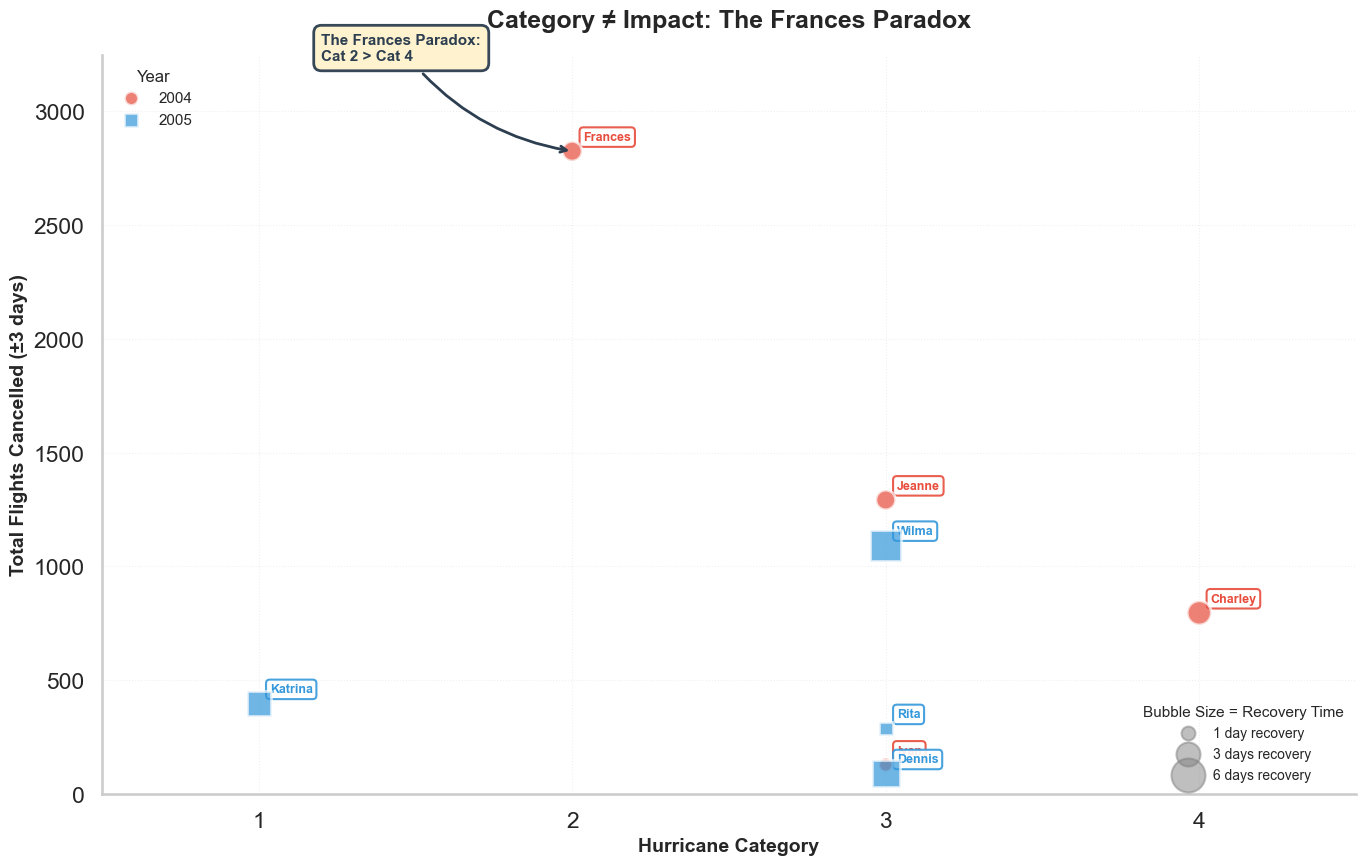

In [82]:
fig, ax = plt.subplots(figsize=(14, 9))

# Prepare data
scatter_data = []
for _, hurricane in hurricanes.iterrows():
    h_impact = impact_df[impact_df['HurricaneName'] == hurricane['HurricaneName']].iloc[0]
    h_recovery = recovery_summary[recovery_summary['HurricaneName'] == hurricane['HurricaneName']].iloc[0]
    
    scatter_data.append({
        'Name': hurricane['HurricaneName'],
        'Category': hurricane['Category'],
        'TotalCancelled': h_impact['total_flights_lost'],
        'RecoveryDays': h_recovery['RecoveryDays'] if h_recovery['RecoveryDays'] > 0 else 1,
        'Year': hurricane['Date'].year
    })

scatter_df = pd.DataFrame(scatter_data)

# Plot by year with different colors
colors_map = {2004: '#e74c3c', 2005: '#3498db'}
markers_map = {2004: 'o', 2005: 's'}

for year in [2004, 2005]:
    year_data = scatter_df[scatter_df['Year'] == year]
    
    scatter = ax.scatter(
        year_data['Category'],
        year_data['TotalCancelled'],
        s=year_data['RecoveryDays'] * 100,  # Size = recovery days
        c=colors_map[year],
        alpha=0.7,
        edgecolors='white',
        linewidth=2,
        marker=markers_map[year],
        label=f'{year} hurricanes',
        zorder=10
    )
    
    # Add labels for each hurricane
    for _, row in year_data.iterrows():
        ax.annotate(
            row['Name'],
            xy=(row['Category'], row['TotalCancelled']),
            xytext=(8, 8),
            textcoords='offset points',
            fontsize=9,
            fontweight='semibold',
            color=colors_map[year],
            bbox=dict(
                boxstyle='round,pad=0.3',
                facecolor='white',
                edgecolor=colors_map[year],
                alpha=0.9,
                linewidth=1.5
            )
        )

# Add "The Frances Paradox" annotation
frances_row = scatter_df[scatter_df['Name'] == 'Frances'].iloc[0]
charley_row = scatter_df[scatter_df['Name'] == 'Charley'].iloc[0]

ax.annotate(
    'The Frances Paradox:\nCat 2 > Cat 4',
    xy=(frances_row['Category'], frances_row['TotalCancelled']),
    xytext=(frances_row['Category'] - 0.8, frances_row['TotalCancelled'] + 400),
    fontsize=11,
    fontweight='bold',
    color='#2c3e50',
    arrowprops=dict(
        arrowstyle='->',
        color='#2c3e50',
        lw=2,
        connectionstyle='arc3,rad=0.2'
    ),
    bbox=dict(
        boxstyle='round,pad=0.5',
        facecolor='#fff3cd',
        edgecolor='#2c3e50',
        alpha=0.95,
        linewidth=2
    ),
    zorder=15
)

# Styling
ax.set_xlabel('Hurricane Category', fontsize=14, fontweight='semibold')
ax.set_ylabel('Total Flights Cancelled (±3 days)', fontsize=14, fontweight='semibold')
ax.set_title('Category ≠ Impact: The Frances Paradox', 
             fontsize=18, fontweight='bold', pad=20)

# Set integer ticks for category
ax.set_xticks([1, 2, 3, 4])
ax.set_xlim(0.5, 4.5)
ax.set_ylim(bottom=0, top=scatter_df['TotalCancelled'].max() * 1.15)

# Legend with size explanation
legend_elements = [
    plt.scatter([], [], s=100, c='#e74c3c', marker='o', alpha=0.7, 
                edgecolors='white', linewidth=2, label='2004'),
    plt.scatter([], [], s=100, c='#3498db', marker='s', alpha=0.7, 
                edgecolors='white', linewidth=2, label='2005'),
]
legend1 = ax.legend(handles=legend_elements, loc='upper left', fontsize=11, 
                    framealpha=0.95, title='Year', title_fontsize=12)

# Add size legend
size_legend_elements = [
    plt.scatter([], [], s=100, c='gray', alpha=0.5, label='1 day recovery'),
    plt.scatter([], [], s=300, c='gray', alpha=0.5, label='3 days recovery'),
    plt.scatter([], [], s=600, c='gray', alpha=0.5, label='6 days recovery'),
]
legend2 = ax.legend(handles=size_legend_elements, loc='lower right', fontsize=10,
                    framealpha=0.95, title='Bubble Size = Recovery Time', title_fontsize=11)
ax.add_artist(legend1)

ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.8)
sns.despine()
plt.tight_layout()
plt.show()

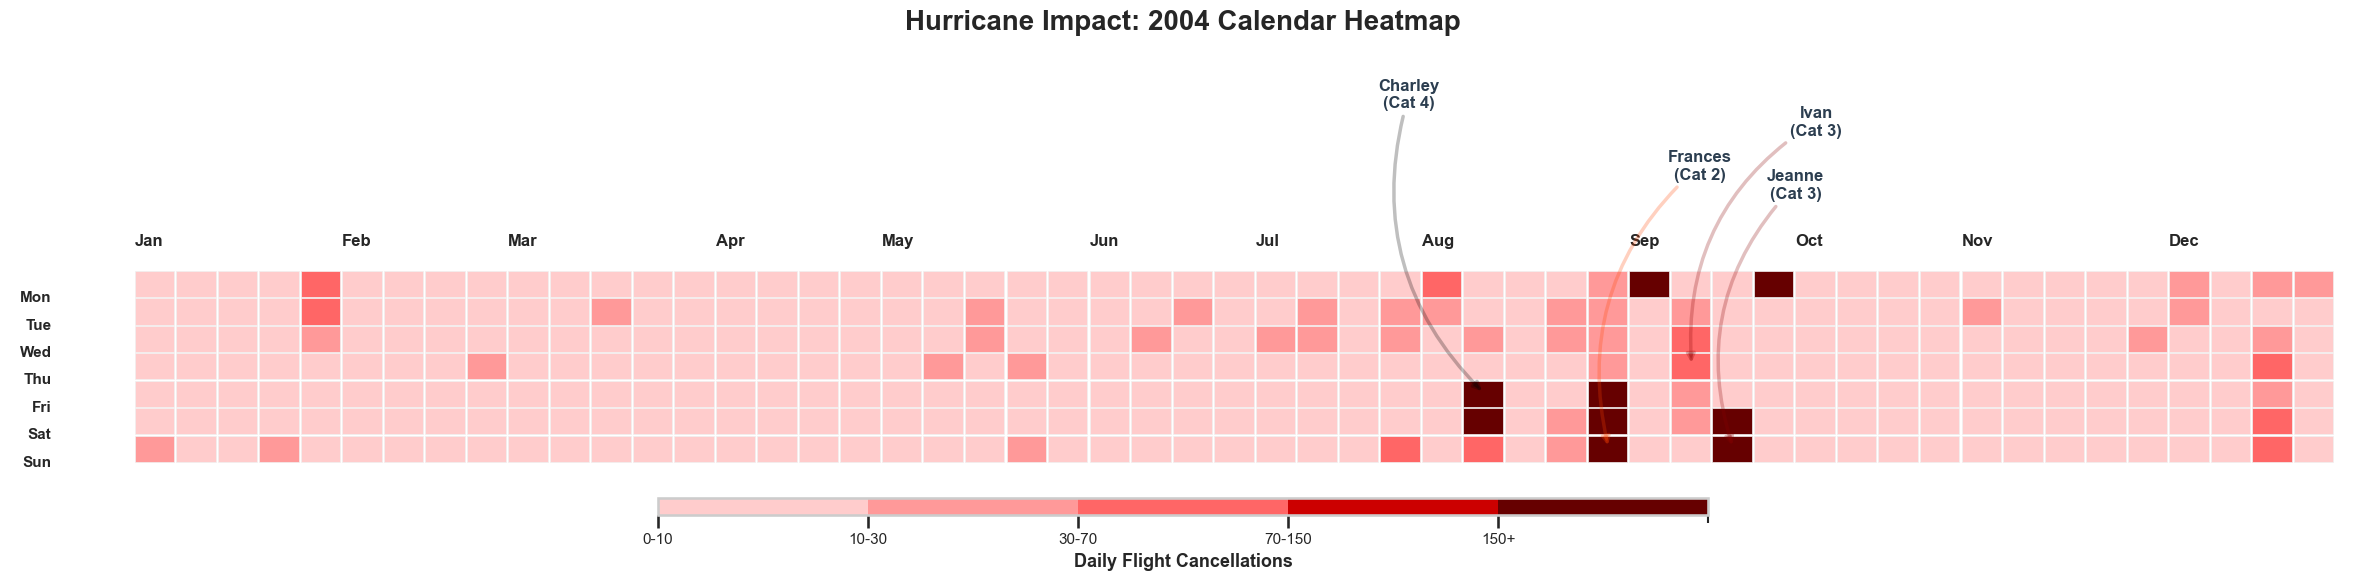

In [122]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap, BoundaryNorm
import numpy as np

# Single subplot for 2004 only
fig, ax = plt.subplots(figsize=(24, 6))

# 5 distinct colors - light to dark red
colors = ['#ffcccc', '#ff9999', '#ff6666', '#cc0000', '#660000']

# 5 bins for cancellation ranges
boundaries = [0, 10, 30, 70, 150, 1000]
norm = BoundaryNorm(boundaries, len(colors))

# Create discrete colormap
cmap = LinearSegmentedColormap.from_list('github', colors, N=len(colors))

# Get all days in 2004
year = 2004
start_date = f'{year}-01-01'
end_date = f'{year}-12-31'
year_data = daily_stats[
    (daily_stats['FlightDate'] >= start_date) &
    (daily_stats['FlightDate'] <= end_date)
].copy()

year_data['Week'] = year_data['FlightDate'].dt.isocalendar().week
year_data['DayOfWeek'] = year_data['FlightDate'].dt.dayofweek
year_data['Month'] = year_data['FlightDate'].dt.month

# Create pivot table - each cell is average cancellations for that day/week
pivot_data = year_data.pivot_table(
    values='Cancelled',
    index='DayOfWeek',
    columns='Week',
    aggfunc='mean',
    fill_value=0
)

# Plot each cell as a colored rectangle
for row_idx, day in enumerate(range(7)):
    for col_idx, week in enumerate(pivot_data.columns):
        if day in pivot_data.index:
            value = pivot_data.loc[day, week]
            
            # Map value to color bin
            norm_value = norm(value)
            color = cmap(norm_value / (len(colors) - 1))
            
            # Draw rectangle
            rect = mpatches.Rectangle(
                (col_idx, 6 - row_idx),
                0.95, 0.95,
                facecolor=color,
                edgecolor='#f0f0f0',
                linewidth=0.5
            )
            ax.add_patch(rect)

# Month labels at top
month_positions = {}
for week in pivot_data.columns:
    week_dates = year_data[year_data['Week'] == week]
    if len(week_dates) > 0:
        month = week_dates['FlightDate'].iloc[0].month
        if month not in month_positions:
            month_positions[month] = list(pivot_data.columns).index(week)

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

for month, pos in month_positions.items():
    ax.text(pos, 7.8, month_names[month-1], 
           fontsize=12, ha='left', va='bottom', fontweight='bold')

# Day labels on left
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
for i, day_name in enumerate(day_names):
    ax.text(-2, 6-i, day_name, fontsize=11, ha='right', va='center', fontweight='semibold')

# Hurricane markers with arrows pointing to exact dates
hurricanes_2004 = hurricanes[hurricanes['Date'].dt.year == 2004]
category_colors_h = {
    4: '#000000',
    3: '#8B0000',
    2: '#FF4500',
    1: '#FFA500'
}

# Custom positioning to avoid label overlap
label_y_positions = {
    'Charley': 12.8,
    'Frances': 10.2,
    'Ivan': 11.8,
    'Jeanne': 9.5
}

label_x_offset = {
    'Charley': -1.8,
    'Frances': 2.2,
    'Ivan': 3.0,
    'Jeanne': 1.5
}

for _, h in hurricanes_2004.iterrows():
    h_date = h['Date']
    h_week = h_date.isocalendar()[1]
    h_dow = h_date.dayofweek
    h_name = h['HurricaneName']
    h_cat = h['Category']
    
    if h_week in pivot_data.columns:
        week_idx = list(pivot_data.columns).index(h_week)
        
        # Exact position of hurricane day
        exact_col = week_idx + 0.5
        exact_row = 6 - h_dow + 0.5
        
        # Label position
        label_y = label_y_positions.get(h_name, 11)
        x_offset = label_x_offset.get(h_name, 0)
        label_x = exact_col + x_offset
        
        label_text = f"{h_name}\n(Cat {h_cat})"
        
        ax.annotate(
            label_text,
            xy=(exact_col, exact_row),
            xytext=(label_x, label_y),
            fontsize=12,
            fontweight='bold',
            color='#2c3e50',
            ha='center',
            va='bottom',
            arrowprops=dict(
                arrowstyle='-|>',
                color=category_colors_h.get(h_cat, '#8B0000'),
                lw=2.5,
                alpha=0.25,
                connectionstyle='arc3,rad=0.3'
            ),
            zorder=10
        )

# Set plot limits and remove axes
ax.set_xlim(-3, len(pivot_data.columns) + 0.5)
ax.set_ylim(-0.5, 14)
ax.axis('off')

# Add colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, orientation='horizontal', 
                    pad=0.05, aspect=60, shrink=0.7, fraction=0.04,
                    spacing='uniform')
cbar.set_label('Daily Flight Cancellations', fontsize=13, fontweight='bold')
cbar.set_ticks([0, 10, 30, 70, 150])
cbar.set_ticklabels(['0-10', '10-30', '30-70', '70-150', '150+'])
cbar.ax.tick_params(labelsize=11)

plt.suptitle('Hurricane Impact: 2004 Calendar Heatmap', 
            fontsize=20, fontweight='bold', y=0.98)

plt.tight_layout()
plt.show()


### Key Insights from Calendar Heatmap:

1. **August-September 2004: The Perfect Storm Cluster**
   - Dark red concentration in late August through September shows unprecedented disruption
   - Four major hurricanes (Charley, Frances, Ivan, Jeanne) created a 6-week period of sustained crisis
   - The visual clustering effect reveals why 2004 was so devastating - no recovery time between events

2. **Frances (Sep 5): The Catastrophic Saturday**
   - Darkest cell in entire heatmap despite being "only" Category 2
   - Weekend timing amplified passenger impact across Florida airports
   - Size and slow movement mattered more than wind speed for operational disruption

3. **Temporal Patterns Visible at a Glance**
   - June-July: Scattered light pink = normal summer weather delays (10-30 cancellations)
   - August-September: Dark red clusters = hurricane season chaos (150+ cancellations)
   - October-December: Return to baseline pink = system recovery

4. **Day-of-Week Effects**
   - Hurricane impacts span multiple days vertically (entire week disrupted)
   - Weekends show darker colors when hurricanes hit - higher flight volumes
   - Mondays following weekend hurricanes also show elevated cancellations (ripple effect)

5. **Geographic Precision Through Temporal Data**
   - Each hurricane's exact landfall date marked with arrow
   - Category color-coding (black=Cat 4, dark red=Cat 3, orange=Cat 2) shows intensity didn't predict impact
   - Ivan's minimal impact visible despite Cat 3 status - demonstrates importance of storm track vs. intensity

6. **The Calendar View Advantage**
   - GitHub-style heatmap makes 365 days scannable in one visualization
   - Seasonal patterns immediately obvious: quiet winter/spring, chaotic late summer
   - Reveals that 2004's hurricane problem wasn't just frequency - it was **clustering**
